# Sedimentation of a Brownian Sphere

This Jupyter Notebook allows to get information from the sedimentation of a sphere in a viscous liquid. Namely, the bulk viscosity $\eta$ of the liquid is obtained through the transverse mean squared displacement of the sphere. Then, the sedimentation speed $v_\mathrm{s}$ of the sphere gives its buyoant mass $\Delta \rho$:
\begin{equation}
    v_\mathrm{s} = \dfrac{mg}{6\pi\eta a} = \dfrac{2}{9} \, \dfrac{a^2 g}{\eta} \, \Delta\rho \, .
\end{equation}
The radius $a$ of the sphere is determined beforehand by holography. 

# Importations

In [1]:
import numpy as np
from scipy.io import loadmat, savemat
from scipy.optimize import curve_fit

In [2]:
import ComputeObservables as co

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib as mpl
from matplotlib import rc
from mpltools import annotation

rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=1)
rc('xtick', direction='in', labelsize=9)
rc('ytick', direction='in', labelsize=9)

rc('font', family='serif', size=9)
rc('text', usetex=True)

rc('figure', dpi=200)
rc('savefig', dpi=200)

# Get Data And Choose the Time Interval

In [4]:
directory = './data/20251125_AR1000/sedimentation/traj_rp_0p9959_np_1p4463_vid_sedimentation.mat'

In [5]:
index = directory.rfind('/')
filename = directory[index+1:-4]
del index 
print('Filename = {}'.format(filename))

Filename = traj_rp_0p9959_np_1p4463_vid_sedimentation


In [10]:
# Input values

upward = False

r_p = 1.0771 * 1e-6
rho_p = 1070

eta_m = 0.00095 # Values at 20 degrees Celsius
rho_m = 1000

fps = 100

g = 9.81

In [11]:
# Prepare save dictionnary
save = {
    'directory': directory, 
    'r_p': r_p, 
    'fps': fps,
    'upward': upward, 
}

In [12]:
# Load Data

raw_data = co.open_xyz_mat(directory, upward=upward, version='new')

In [13]:
raw_data

array([[3.89499327e-05, 3.55049501e-05, 4.94457255e-05],
       [3.89423168e-05, 3.55264420e-05, 4.96964212e-05],
       [3.89856743e-05, 3.55339033e-05, 4.93990631e-05],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]], shape=(24477, 3))

In [14]:
# Remove zeros at the end of the trajectory:
try:
    ind = list(raw_data[:,0]).index(0)
    raw_data = raw_data[:ind,:]
except ValueError:
    print('No pb. No zero in raw data.')

In [15]:
# Save raw data (without zeros at the end) 
save['raw_data'] = raw_data

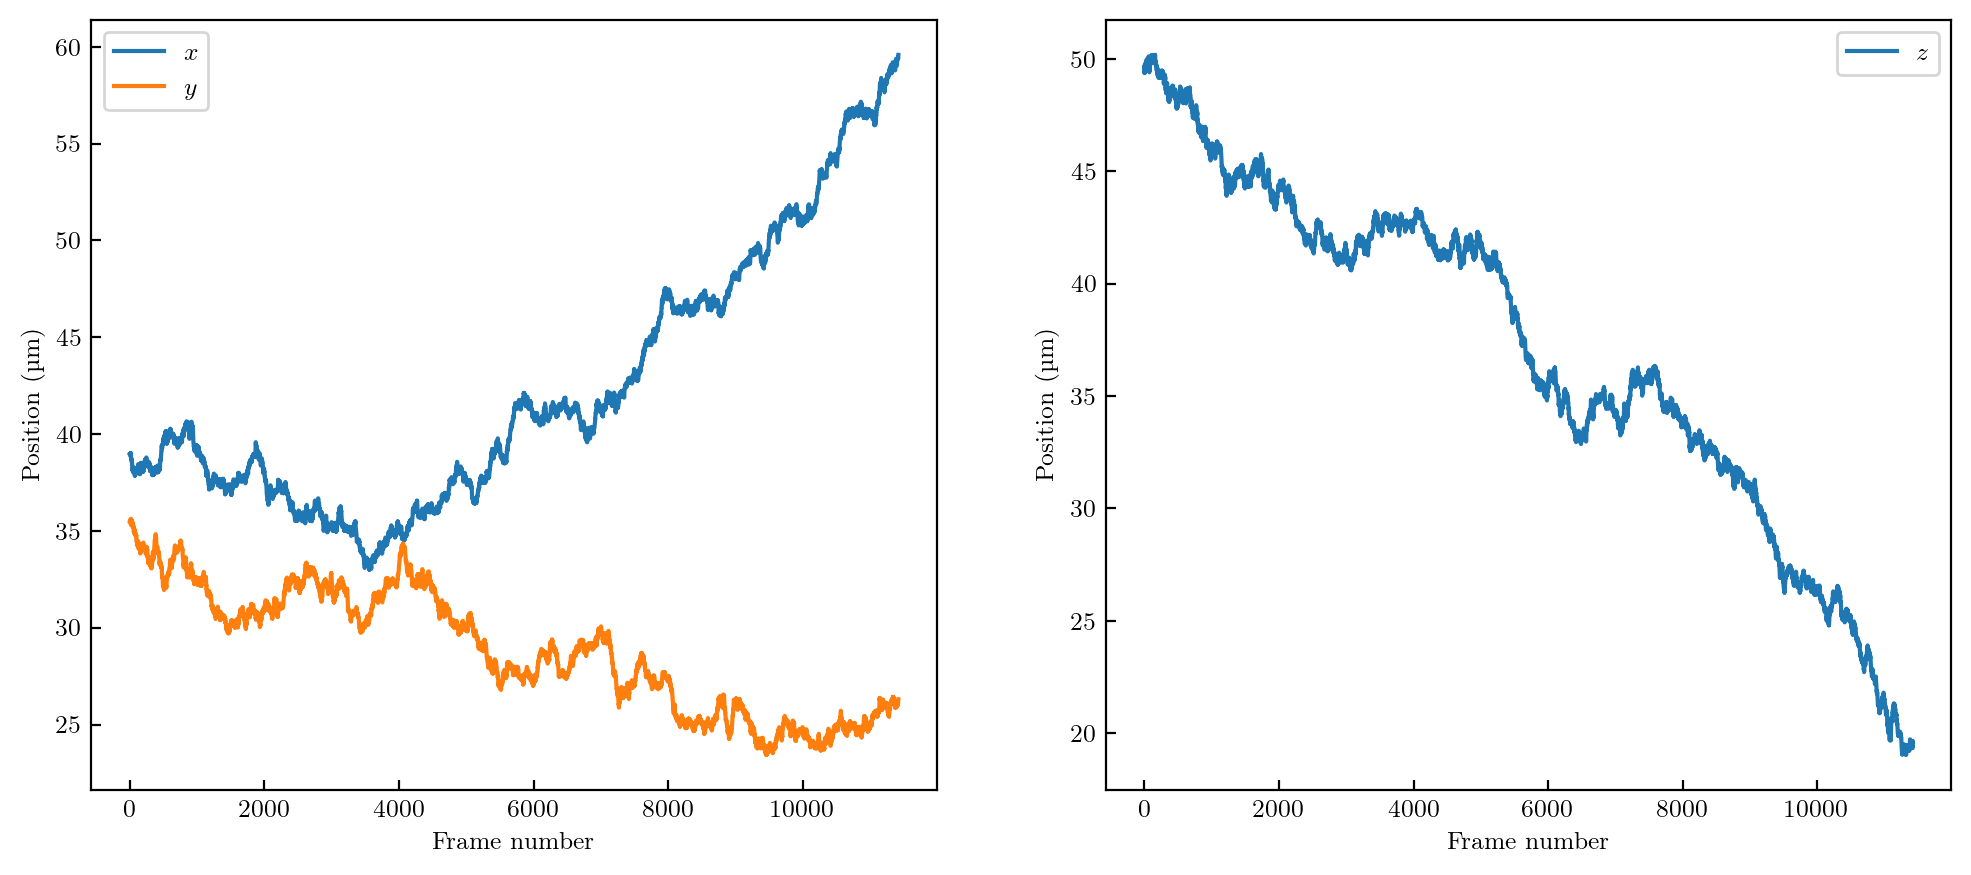

In [16]:
# Quick Plot

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axx, axz = axes[0], axes[1]

# fig.canvas.toolbar_visible = True
# fig.canvas.header_visible = True
# fig.canvas.resizable = True

axx.plot(raw_data[:, 0] * 1e6, label="$x$")
axx.plot(raw_data[:, 1] * 1e6, label="$y$")
axz.plot(raw_data[:, 2] * 1e6, label="$z$")

axx.set_xlabel("Frame number")
axx.set_ylabel("Position (µm)")
axz.set_xlabel("Frame number")
axz.set_ylabel("Position (µm)")

axx.legend()
axz.legend()

plt.show()

In [17]:
min_z = np.min(raw_data[:,2])
# min_z = - 5.8e-6
min_z

np.float64(1.9037004746237705e-05)

In [18]:
cutoff_z = min_z + 10 * r_p
z = raw_data[:,2]
condition = (z >= cutoff_z)
frame_to_cutoff = len(condition[condition==True])
print('Particle is above ten radii until frame {}'.format(frame_to_cutoff))

Particle is above ten radii until frame 9171


In [19]:
# # Plot for pres

# fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

# ax.plot(np.arange(len(raw_data[:,2]))/fps, (raw_data[:, 2] - np.max(raw_data[:,2])) * 1e6, c='tab:red')
# ax.plot(np.arange(len(raw_data[:,2]))/fps, np.zeros(len(raw_data[:,2])), ls='--', c='k')
        
# ax.set(
#     xlabel="Time (s)",
#     ylabel=r"Sphere-wall gap (µm)",
#     xscale='linear', 
#     yscale='linear', 
# )

# # ax.legend()

# plt.tight_layout()
# plt.show()

# # fig.savefig('upward_sedimentation.pdf')

In [20]:
# Choose Time Interval 
start = 0
stop = 9000

In [21]:
raw_data = raw_data[start:stop,:]
time = np.arange(len(raw_data[:,0])) / fps 

In [22]:
save['start'] = start 
save['stop'] = stop

In [23]:
del start, stop

# Begin

In [24]:
x = raw_data[:,0]
y = raw_data[:,1]
z = raw_data[:,2]

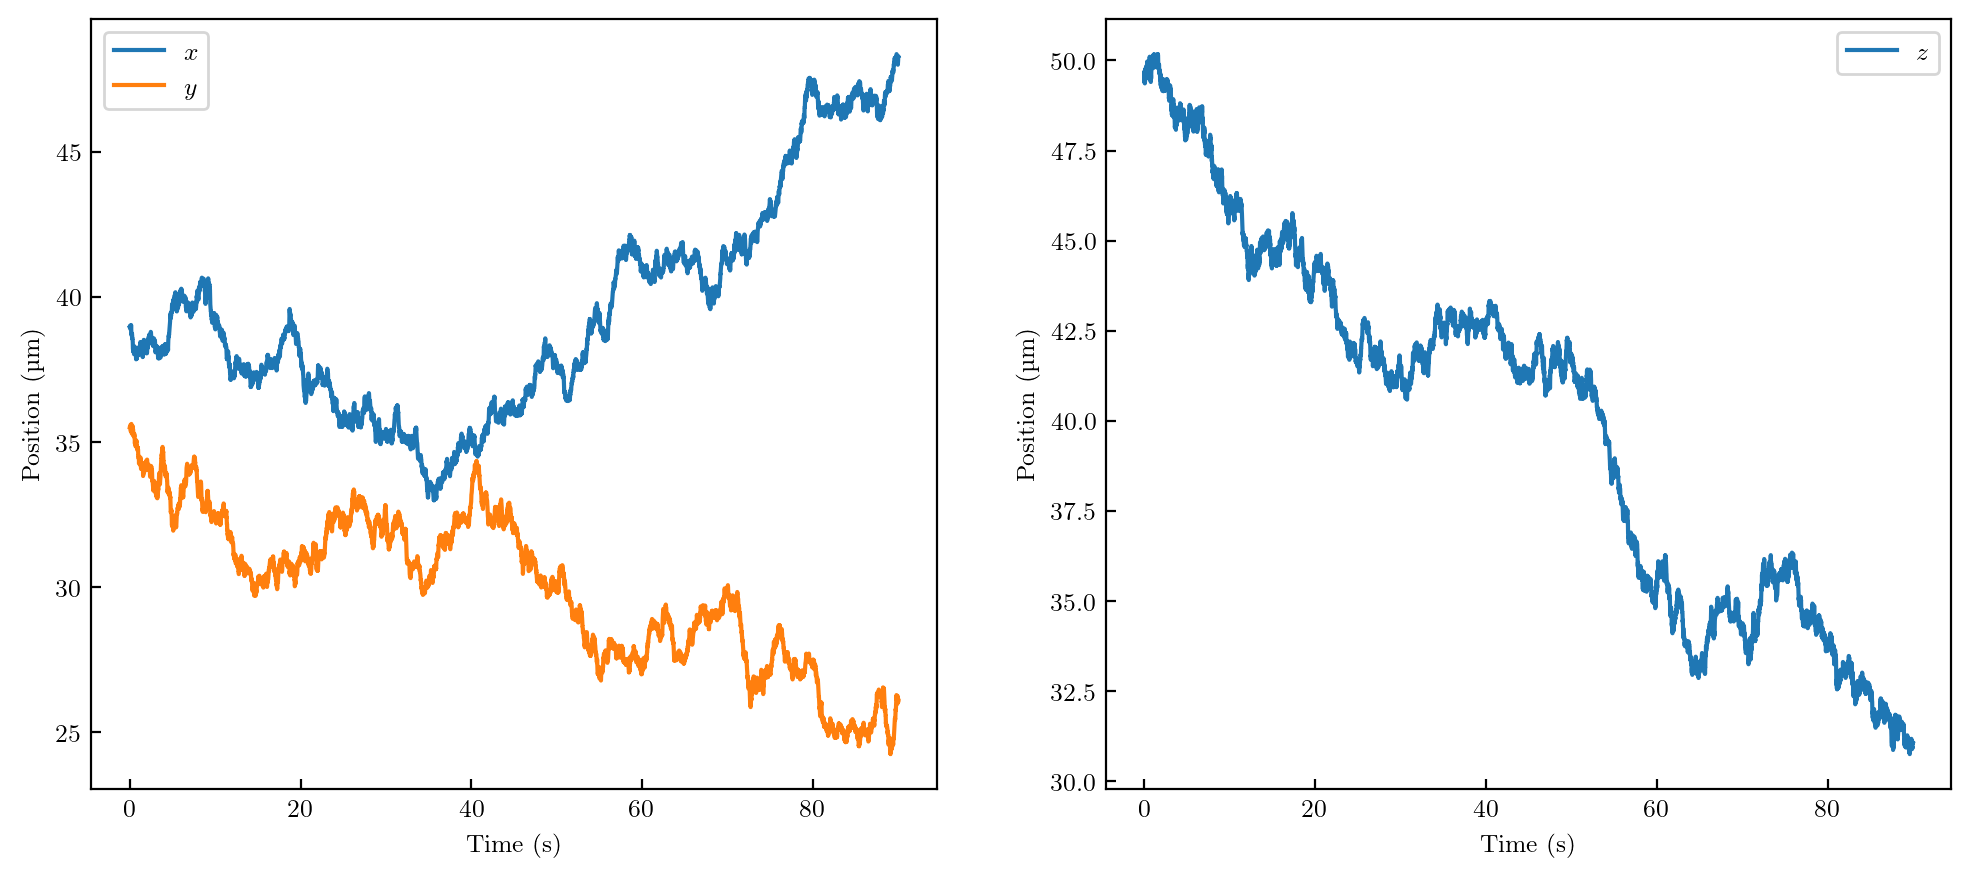

In [25]:
# Quick Plot

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axx, axz = axes[0], axes[1]

axx.plot(time, x * 1e6, label="$x$")
axx.plot(time, y * 1e6, label="$y$")
axz.plot(time, z * 1e6, label="$z$")

axx.set_xlabel("Time (s)")
axx.set_ylabel("Position (µm)")
axz.set_xlabel("Time (s)")
axz.set_ylabel("Position (µm)")

axx.legend()
axz.legend()

plt.show()

In [26]:
##########

#####

# Specify the wall position

#####

##########

wall_position = 21.5e-6

##########

#####

# Specify the wall position

#####

##########

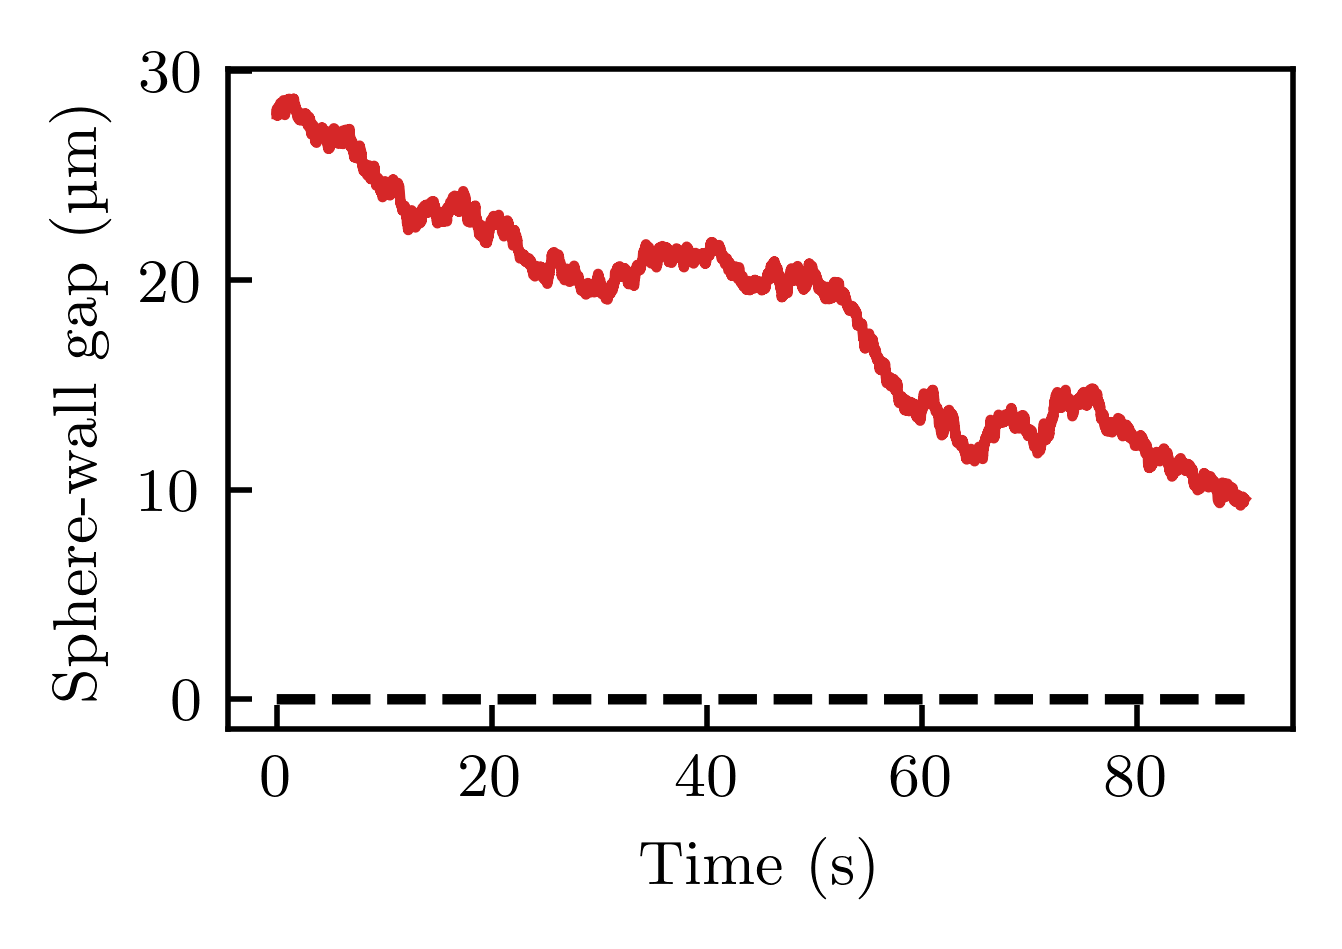

In [27]:
# Plot for pres

fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

ax.plot(np.arange(len(raw_data[:,2]))/fps, (raw_data[:, 2] - wall_position) * 1e6, c='tab:red')
ax.plot(np.arange(len(raw_data[:,2]))/fps, np.zeros(len(raw_data[:,2])), ls='--', c='k')
        
ax.set(
    xlabel="Time (s)",
    ylabel=r"Sphere-wall gap (µm)",
    xscale='linear', 
    yscale='linear', 
)

# ax.legend()

plt.tight_layout()
plt.show()

# fig.savefig('sedimentation_raw_water_EG_w30_expected.pdf')

In [28]:
save['wall_position'] = wall_position

# Define Time Intervals

In [29]:
delta_frame_nb = np.concatenate(
    (
        np.arange(1, 10, 1),
        np.arange(10, 100, 10),
        np.arange(100, 1000, 100),
        np.arange(1000, 8000, 1000),
        # np.arange(1000, 10000, 1000),
        # np.arange(10000, 15000, 1000), 
    )
)

delta_time = time[delta_frame_nb]

# Determine the Bulk Viscosity Via MSD (parallel to the wall)

In [30]:
# MSD 

MSD_x, std_MSD_x = co.moment(2, x, delta_frame_nb, return_std = True) # Function in wrapper
MSD_y, std_MSD_y = co.moment(2, y, delta_frame_nb, return_std = True)
MSD_z, std_MSD_z = co.moment(2, z, delta_frame_nb, return_std = True)

MSD_para = (MSD_x + MSD_y) / 2
std_MSD_para = (std_MSD_x + std_MSD_y) / 2
MSD_perp = np.copy(MSD_z)
std_MSD_perp = np.copy(std_MSD_z)

# del MSD_x, MSD_y, MSD_z
del std_MSD_x, std_MSD_y, std_MSD_z

In [31]:
# Expected values
D0_th = 4e-21 / (6 * np.pi * eta_m * r_p)
vs_th = 2/9 * r_p**2 * g / eta_m * np.abs(rho_m - rho_p)
tau_c = D0_th / vs_th**2

print('Expected values:')
print("D0 = {0:.3e} m^2".format(D0_th))
print("v = {0:.3e} m/s".format(vs_th))
print("Cross-over time (approx) = {0:.1f} s".format(tau_c))

Expected values:
D0 = 2.074e-13 m^2
v = 1.864e-07 m/s
Cross-over time (approx) = 6.0 s


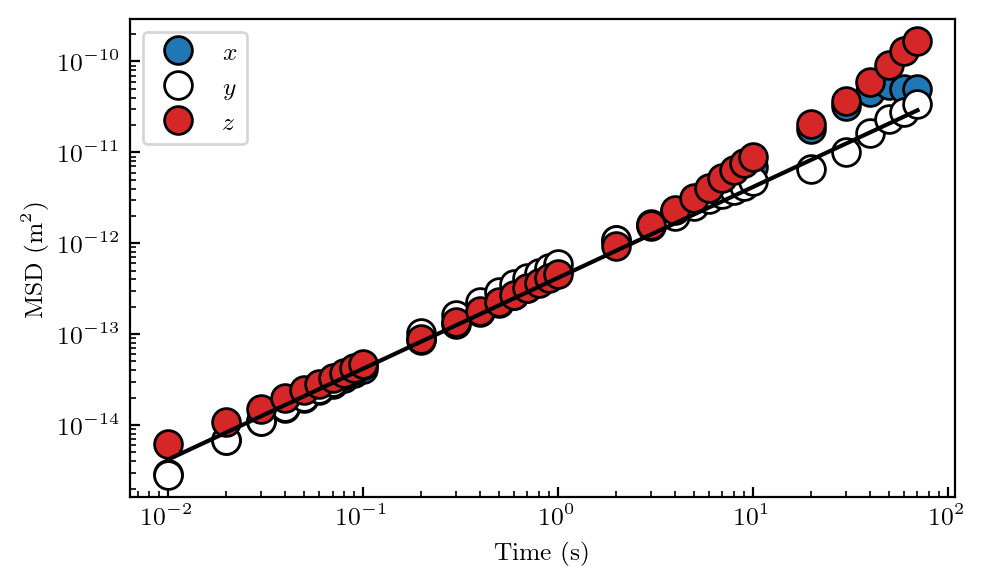

In [33]:
fig, ax = plt.subplots(1, 1, figsize = (5, 3))

ax.plot(delta_time, MSD_x, 'o', markerfacecolor='tab:blue', markersize=10, markeredgecolor='k', markeredgewidth=1, label="$x$")
ax.plot(delta_time, MSD_y, 'o', markerfacecolor='w', markersize=10, markeredgecolor='k', markeredgewidth=1, label="$y$")
ax.plot(delta_time, MSD_z, 'o', markerfacecolor='tab:red', markersize=10, markeredgecolor='k', markeredgewidth=1, label="$z$")

ax.plot(delta_time, 2*D0_th*delta_time + 0 * vs_th**2*delta_time**2, ls='-', c='k')

ax.legend()
ax.set(
    xscale='log',
    yscale='log', 
    xlabel='Time (s)', 
    ylabel=r'MSD $\mathrm{(m^2)}$', 
)

plt.tight_layout()
plt.show()

In [34]:
def MSD_th(dt, D=D0_th, noise=0, v=0):
    return 2*D*dt + (2*noise)**2 + (v*dt)**2

In [35]:
# Fit

# Define time intervals (short and long times)
stop_short = 1 # s
start_long = 1 # s

MSD_short = lambda dt, D, noise: MSD_th(dt, D, noise=noise)

popt_MSD_x, _ = curve_fit(MSD_short, delta_time[delta_time < stop_short], MSD_x[delta_time < stop_short], p0=[D0_th,0])
popt_MSD_z_short, _ = curve_fit(MSD_short, delta_time[delta_time < stop_short], MSD_z[delta_time < stop_short], p0=[D0_th,0])

D_para = popt_MSD_x[0]
D_perp = popt_MSD_z_short[0]
noise_para_from_MSD = popt_MSD_x[1]
noise_perp_from_MSD = popt_MSD_z_short[1]

MSD_long = lambda dt, v: MSD_th(dt, D=D_perp, noise=noise_perp_from_MSD, v=v)

popt_MSD_z_long, _ = curve_fit(MSD_long, delta_time[delta_time > start_long], MSD_z[delta_time > start_long], p0=[0])

v_s_from_MSD = popt_MSD_z_long[0]

if (upward == False) and v_s_from_MSD > 0: 
    v_s_from_MSD *= -1 

/var/folders/w9/dz7zwdw15hv1n7xycd9mhbwh0000gn/T/ipykernel_20632/1245668535.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_MSD_x, _ = curve_fit(MSD_short, delta_time[delta_time < stop_short], MSD_x[delta_time < stop_short], p0=[D0_th,0])


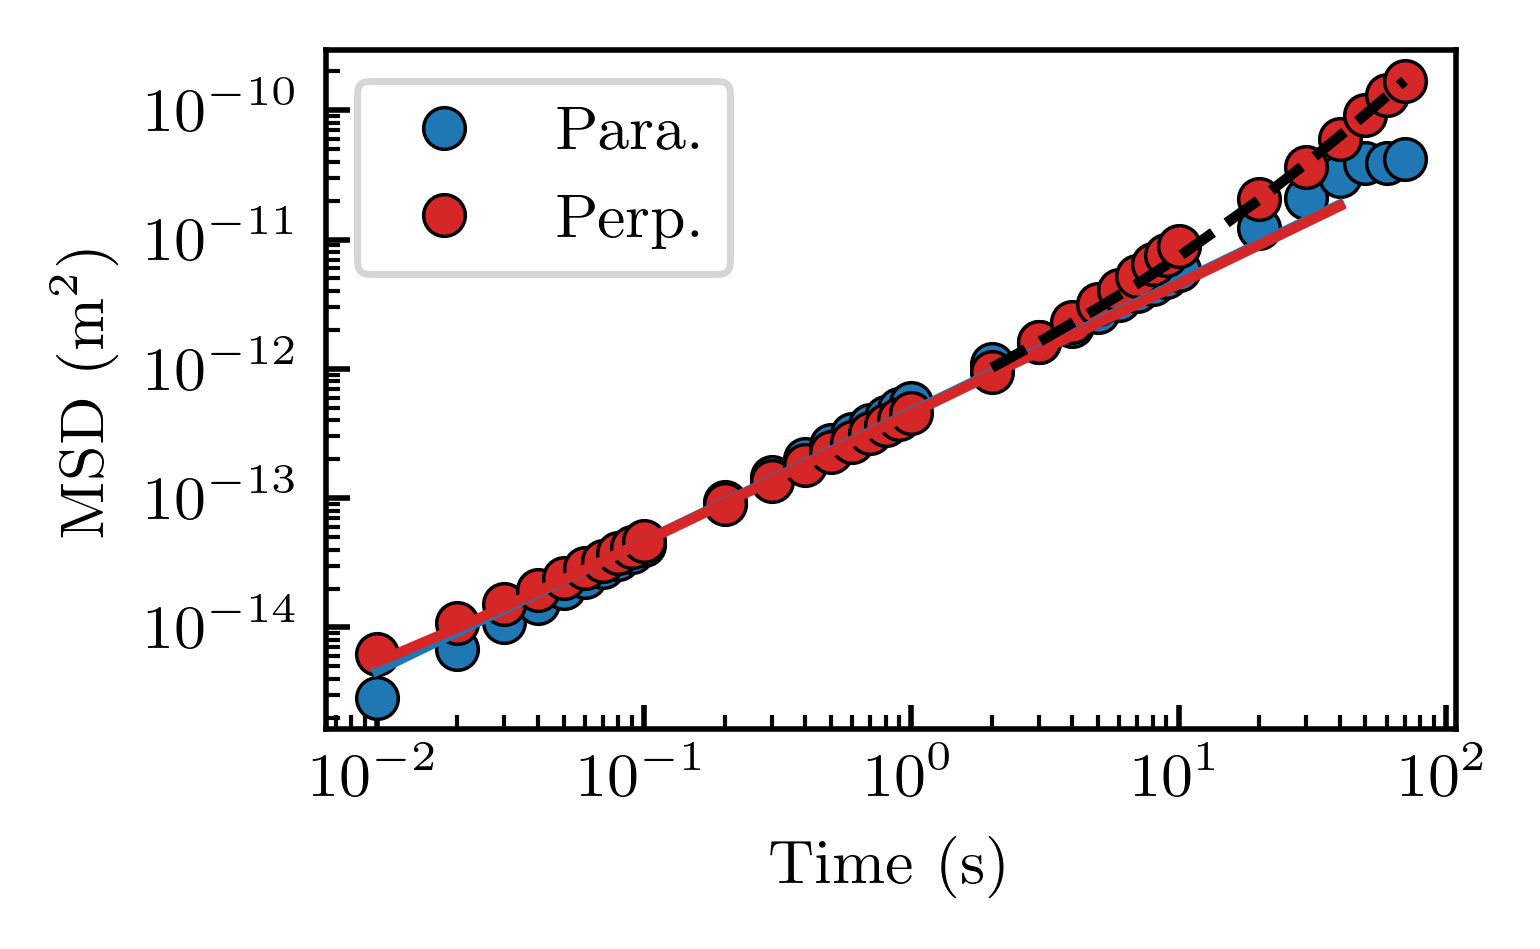

FYI, expected D0 = 2.074e-13 m^2/s
The measured diffusion coefficents are:
   Para: 1.118 the expected value
   Perp: 1.093 the expected value
The measured noise levels are:
   0.001 nm in the parallel direction
   14.627 nm in the normal direction
The measured sedimentation speed is:
   -1.675e-07 m/s


In [37]:
fig, ax = plt.subplots(1, 1, figsize = (8 / 2.54, 5 / 2.54), dpi=500)

ax.plot(delta_time, MSD_para, 'o', markerfacecolor='tab:blue', markersize=6, markeredgecolor='k', markeredgewidth=0.5, label="Para.")
ax.plot(delta_time, MSD_perp, 'o', markerfacecolor='tab:red', markersize=6, markeredgecolor='k', markeredgewidth=0.5, label="Perp.")

ax.plot(delta_time[delta_time < 50], MSD_short(delta_time[delta_time < 50], *popt_MSD_x), ls='-', c='tab:blue', linewidth=1.5)
ax.plot(delta_time[delta_time < 50], MSD_short(delta_time[delta_time < 50], *popt_MSD_z_short), ls='-', c='tab:red', linewidth=1.5)
ax.plot(delta_time[delta_time > start_long], MSD_long(delta_time[delta_time > start_long], *popt_MSD_z_long), ls='--', c='k', linewidth=1.5)

ax.legend()
ax.set(
    xscale='log',
    yscale='log', 
    xlabel='Time (s)', 
    ylabel=r'MSD $\mathrm{(m^2)}$', 
)

plt.tight_layout()
plt.show()

# fig.savefig('fig_upward_sedimentation_MSD_with_noise.pdf')

print("FYI, expected D0 = {0:.3e} m^2/s".format(D0_th))
print("The measured diffusion coefficents are:")
print("   Para: {0:.3f} the expected value".format(D_para / D0_th))
print("   Perp: {0:.3f} the expected value".format(D_perp / D0_th))
print("The measured noise levels are:")
print("   {0:.3f} nm in the parallel direction".format(noise_para_from_MSD * 1e9))
print("   {0:.3f} nm in the normal direction".format(noise_perp_from_MSD * 1e9))
print("The measured sedimentation speed is:")
print("   {0:.3e} m/s".format(v_s_from_MSD))

In [38]:
# Determine the viscosity

def eta(D, a=r_p, kT=4e-21):
    return kT / (6 * np.pi * D * a)

In [39]:
eta_m_from_MSD = eta(D_para)
print("The measured medium viscosity = {:.2f} mPa.s".format(eta_m_from_MSD * 1e3))

The measured medium viscosity = 0.85 mPa.s


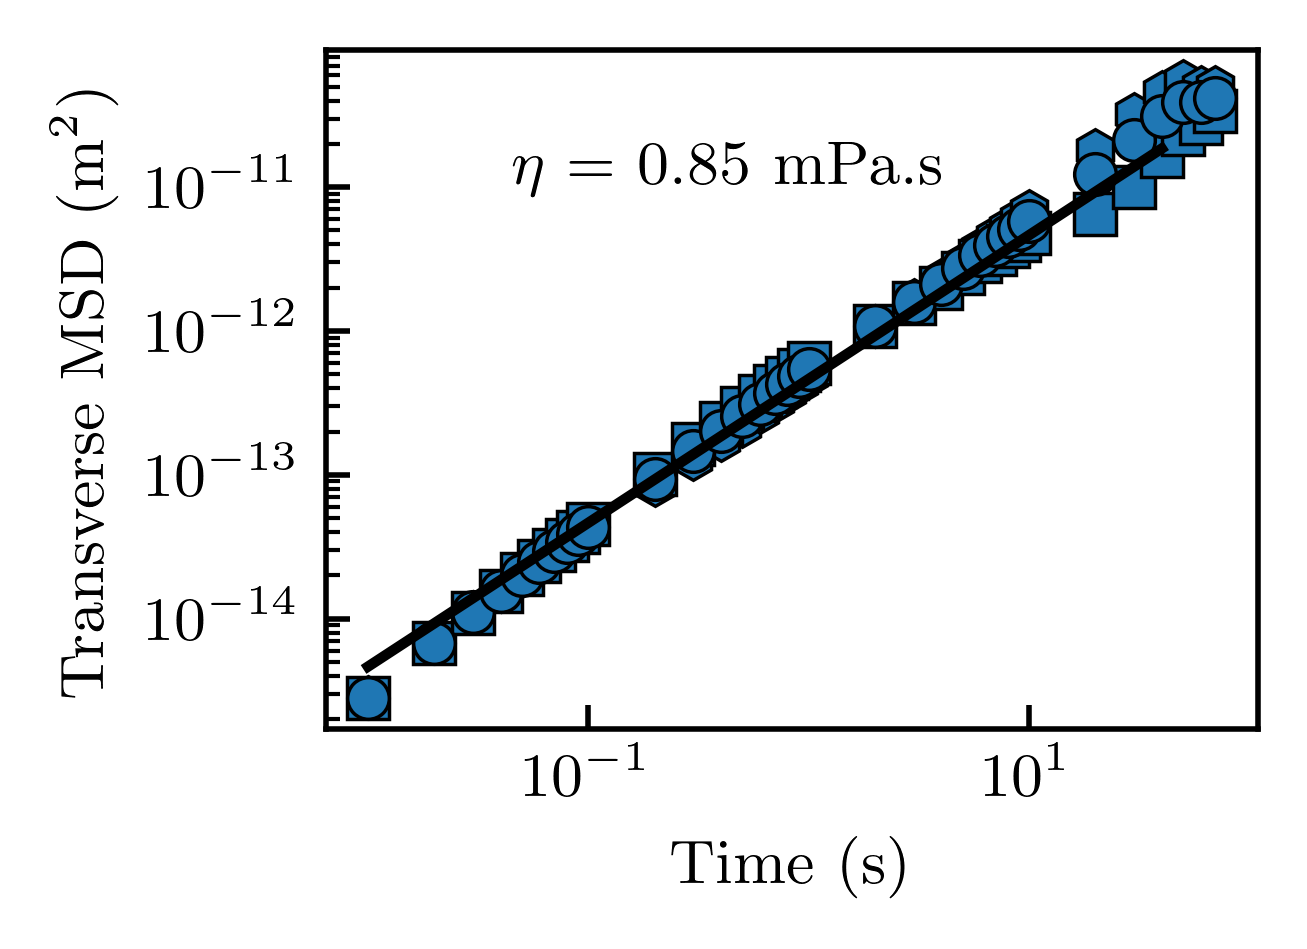

In [41]:
fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

ax.plot(delta_time, MSD_x, 'h', markerfacecolor='tab:blue', markersize=6, markeredgecolor='k', markeredgewidth=0.5, label="$x$")
ax.plot(delta_time, MSD_y, 's', markerfacecolor='tab:blue', markersize=6, markeredgecolor='k', markeredgewidth=0.5, label="$y$")
ax.plot(delta_time, MSD_para, 'o', markerfacecolor='tab:blue', markersize=6, markeredgecolor='k', markeredgewidth=0.5, label="Para.")
ax.plot(delta_time[delta_time < 50], MSD_short(delta_time[delta_time < 50], *popt_MSD_x), ls='-', c='k', linewidth=1.5)

ax.annotate(
    r"$\eta$ = {:.2f} mPa.s".format(eta_m_from_MSD*1e3), 
    xy=(0.2, 0.8), xytext=(0.2,0.8), xycoords='axes fraction', textcoords='axes fraction', 
)

# ax.legend()
ax.set(
    xscale='log',
    yscale='log', 
    xlabel='Time (s)', 
    ylabel=r'Transverse MSD $\mathrm{(m^2)}$', 
)

plt.tight_layout()
plt.show()

# fig.savefig('sedimentation_MSD_para_viscosity.pdf')

In [42]:
# Save 

save['v_s_from_MSD'] = v_s_from_MSD
save['eta_m_from_MSD'] = eta_m_from_MSD

save['delta_time'] = delta_time
save['MSD_para'] = MSD_para
save['MSD_perp'] = MSD_perp

save['stop_short'] = stop_short
save['start_long'] = start_long

save['noise_para_from_MSD'] = noise_para_from_MSD
save['noise_perp_from_MSD'] = noise_perp_from_MSD

In [43]:
# # Figure for MSD z and error 

# fig, axes = plt.subplots(1, 2, figsize=(8/2.54, 8/2.54))
# ax1, ax2 = axes

# ax1.plot(
#     delta_time, MSD_perp, 
#     'o', markerfacecolor='tab:red', markersize=6, markeredgecolor='k', markeredgewidth=0.5
# )

# ax

# Study Sedimentation Via Drifts

In [44]:
def sign_v_s(upward):
    if upward: 
        return 1
    else:
        return -1

def d_rho(v, upward=upward, a=r_p, eta=eta_m, g=g):
    sign = sign_v_s(upward)
    return 9/2 * eta / a**2 / g * v * sign

In [45]:
drift_x, _ = co.moment(1, x, delta_frame_nb, return_std = True) # Function in wrapper
drift_y, _ = co.moment(1, y, delta_frame_nb, return_std = True)
drift_z, _ = co.moment(1, z, delta_frame_nb, return_std = True)

In [46]:
f_drift = lambda dt, v: v*dt

popt_drift_z, _ = curve_fit(f_drift, delta_time, drift_z, p0=[0])

v_s_from_drift = popt_drift_z[0]

print("The measured sedimentation speed is:")
print("   {0:.3e} m/s".format(v_s_from_drift))

The measured sedimentation speed is:
   -1.874e-07 m/s


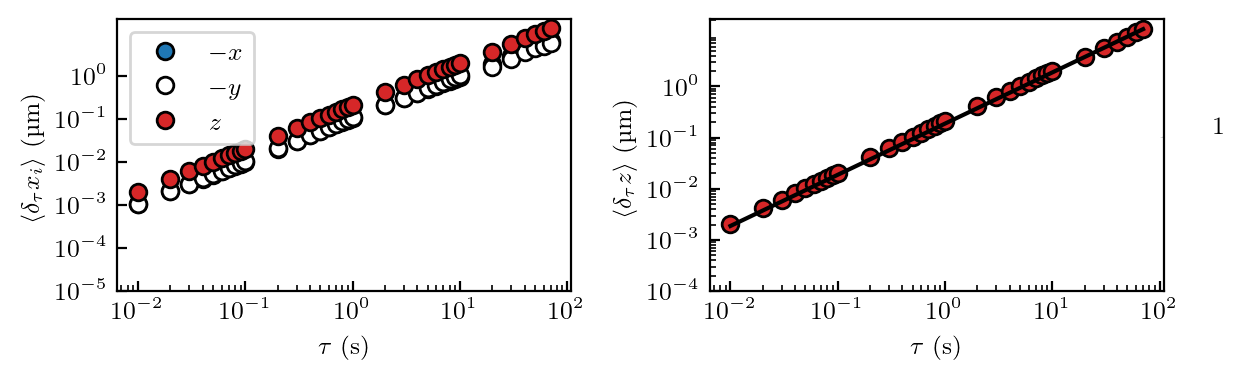

The measured sedimentation speed is:
   -1.874e-07 m/s


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16/2.54,5/2.54))
axx, axz = axes[0], axes[1]

axx.plot(delta_time, np.abs(drift_x) * 1e6, 'o', c='tab:blue', label="$-x$")
axx.plot(delta_time, np.abs(drift_y) * 1e6, 'o', c='w', label="$-y$")
axx.plot(delta_time, np.abs(drift_z) * 1e6, 'o', c='tab:red', label="$z$")
axz.plot(delta_time, np.abs(drift_z) * 1e6, 'o', c='tab:red', label="$z$")
axz.plot(delta_time, np.abs(f_drift(delta_time, *popt_drift_z)) * 1e6, ls='-', c='k')

axx.set(
    xlabel=r"$\tau$ (s)", 
    ylabel=r"$\langle \delta_\tau x_i \rangle$ (µm)", 
    xscale='log', 
    yscale='log', 
    yticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1], 
)
axz.set(
    xlabel=r"$\tau$ (s)", 
    ylabel=r"$\langle \delta_\tau z \rangle$ (µm)", 
    xscale='log', 
    yscale='log', 
    yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1], 
)

axx.legend()

annotation.slope_marker((100, 1e-1), 1, ax=axz)

plt.tight_layout()
plt.show()

print("The measured sedimentation speed is:")
print("   {0:.3e} m/s".format(v_s_from_drift))

In [48]:
delta_rho_from_drift = d_rho(v_s_from_drift, eta=eta_m_from_MSD)
print("Buyoant density = {:.2f} kg/m^3".format(delta_rho_from_drift))

Buyoant density = 62.92 kg/m^3


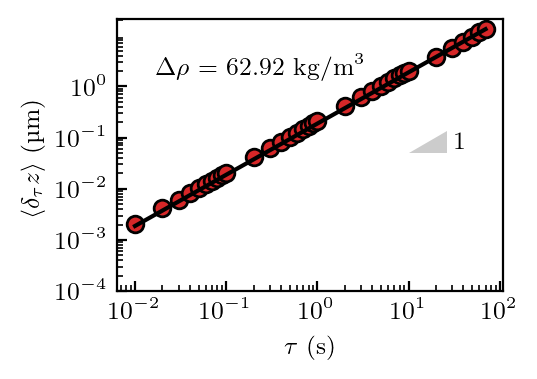

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(7/2.54,5/2.54))

ax.plot(delta_time, np.abs(drift_z) * 1e6, 'o', c='tab:red', label="$z$")
ax.plot(delta_time, np.abs(f_drift(delta_time, *popt_drift_z)) * 1e6, ls='-', c='k')

ax.annotate(
    r"$\Delta\rho$ = {:.2f} kg/m$^3$".format(delta_rho_from_drift), 
    xy=(0.1, 0.8), xytext=(0.1,0.8), xycoords='axes fraction', textcoords='axes fraction', 
)

# ax.legend()
ax.set(
    xlabel=r"$\tau$ (s)", 
    ylabel=r"$\langle \delta_\tau z \rangle$ (µm)", 
    xscale='log', 
    yscale='log', 
    yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1], 
)

annotation.slope_marker((10, 0.05), 1, ax=ax)

plt.tight_layout()
plt.show()

# fig.savefig('sedimentation_drift_perp_density.pdf')

In [50]:
r_p

1.0770999999999998e-06

In [51]:
# Save

save['v_s_from_drift'] = v_s_from_drift
save['delta_rho_from_drift'] = delta_rho_from_drift

save['drift_x'] = drift_x
save['drift_y'] = drift_y
save['drift_z'] = drift_z

In [52]:
# Compare values of the sedimentation velocity
# Obtained from drift and from MSD at long times

delta_rho_from_MSD = d_rho(v_s_from_MSD, eta=eta_m_from_MSD)

print('From drift vs. from MSD:')
print()
print("Sedimentation velocity = {0:.2e} vs. {1:.2e} m/s".format(v_s_from_drift, v_s_from_MSD))
print()
print("Buoyant density = {0:.2f} vs. {1:.2f} kg/m^3".format(delta_rho_from_drift, delta_rho_from_MSD))

From drift vs. from MSD:

Sedimentation velocity = -1.87e-07 vs. -1.68e-07 m/s

Buoyant density = 62.92 vs. 56.26 kg/m^3


In [53]:
save['delta_rho_from_MSD'] = delta_rho_from_MSD

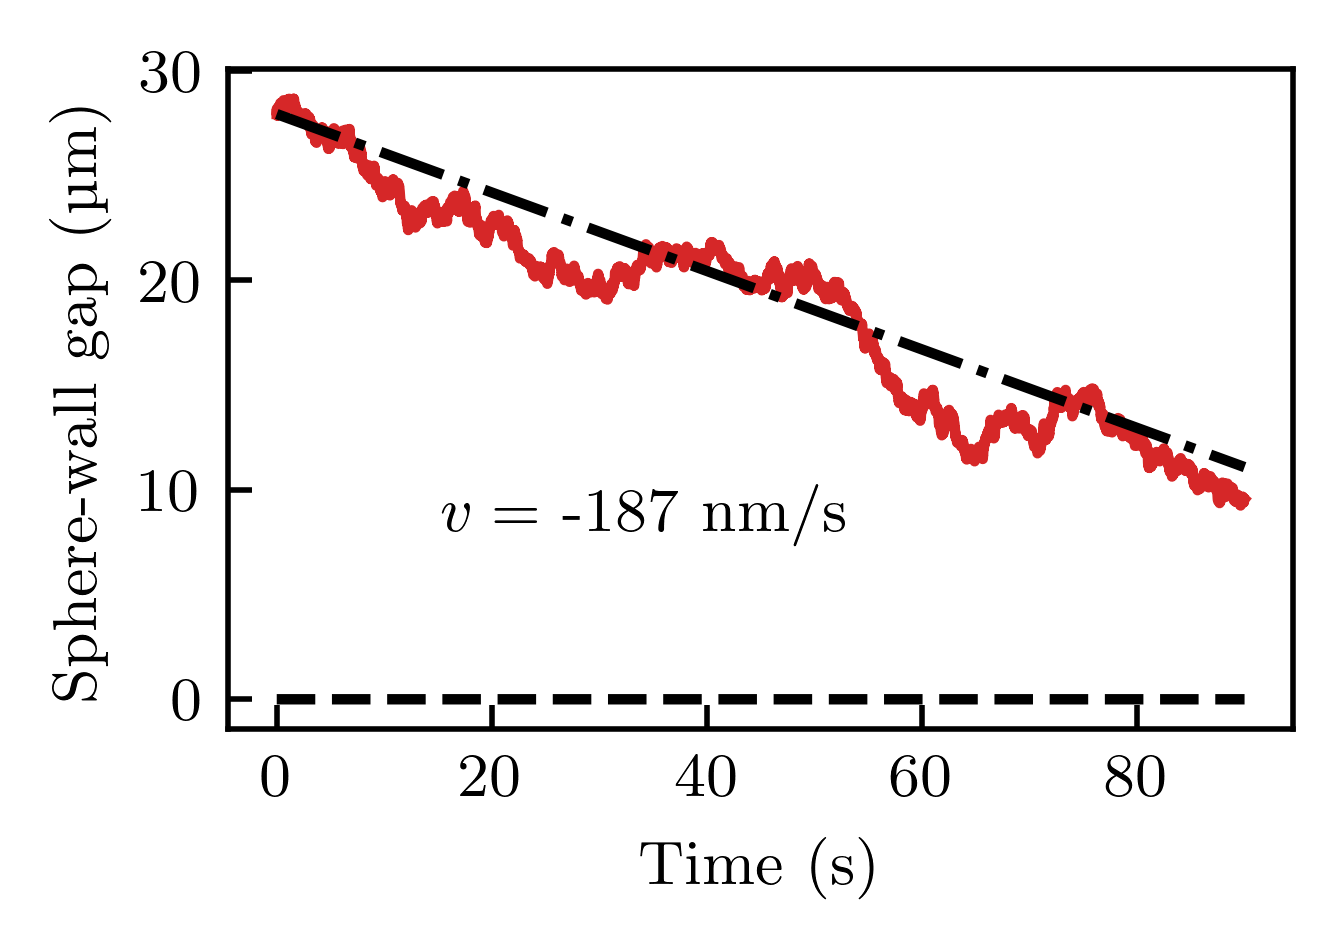

In [54]:
# Plot for pres, with sedimentation speed

fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

ttt = np.arange(len(z))/fps

ax.plot(ttt, (z - wall_position) * 1e6, c='tab:red')
ax.plot(ttt, np.zeros(len(z)), ls='--', c='k')
ax.plot(ttt, (z[0] - wall_position) * 1e6 + v_s_from_drift * ttt * 1e6, '-.k')

ax.annotate(
    r"$v =$ {:.0f} nm/s".format(v_s_from_drift * 1e9), 
    xy=(0.7, 0.4), xytext=(0.2,0.3), xycoords='axes fraction', textcoords='axes fraction', 
)

# ax.legend()
ax.set(
    xlabel="Time (s)",
    ylabel=r"Sphere-wall gap (µm)",
    xscale='linear', 
    yscale='linear', 
)

# annotation.slope_marker((600, 50), (-1, 1), invert=False, ax=ax)

plt.tight_layout()
plt.show()

# fig.savefig('sedimentation_z_with_sedimentation_speed.pdf')

In [56]:
# savemat("sedimentation_20251125_AR1000_water.mat", save, appendmat=True)

# Plot Several Sedimentations

## Data 

In [123]:
directory1 = './20231018_AR1000_water_EG40/sedimentation/data/traj_rp_1p5937_np_1p4606_vid_1_sedimentation.mat'
# directory2 = './20231025_AP100_water_EG30/sedimentation/traj_rp_1p8588_np_1p5003_vid_2nd_part.mat'
directory3 = './20231102_AR1000_water_EG30/sedimentation/1_sedimentation/fit_all_traj_rn_previously_determined/traj_rp_1p587_np_1p4705_vid_fit_all_traj_rn_previously_determined.mat'
directory4 = './20231103_PS6um_water_EG30/sedimentation/traj_rp_3p0106_np_1p5916_vid_1_sedimentation.mat'

In [124]:
fps1 = 100
# fps2 = 100
fps3 = 50
fps4 = 50

In [125]:
wall_1 = -5.76e-6
# wall_2 = 
wall_3 = 13.3e-6
wall_4 = 9.7e-6

In [162]:
data1 = co.open_xyz_mat(directory1, upward=False, version='new')
# data2 = co.open_xyz_mat(directory2, upward=False, version='new')
data3 = co.open_xyz_mat(directory3, upward=False, version='new')
data4 = co.open_xyz_mat(directory4, upward=False, version='new')

In [163]:
# datas = [data1, data2, data3, data4]
# fpss = [fps1, fps2, fps3, fps4]

In [164]:
# zz = np.empty((len(datas)), dtype=np.ndarray)
# wall_positions = np.zeros((len(datas)), dtype=float)

# for i, data in enumerate(datas):
    # z = data[:, 2]
    # zz[i] = np.copy(z)
# del z 

In [172]:
z1 = data1[:80000,2]
# z2 = data2[:,2]
z3 = data3[:100000,2]
z4 = data4[:,2]

## Plot

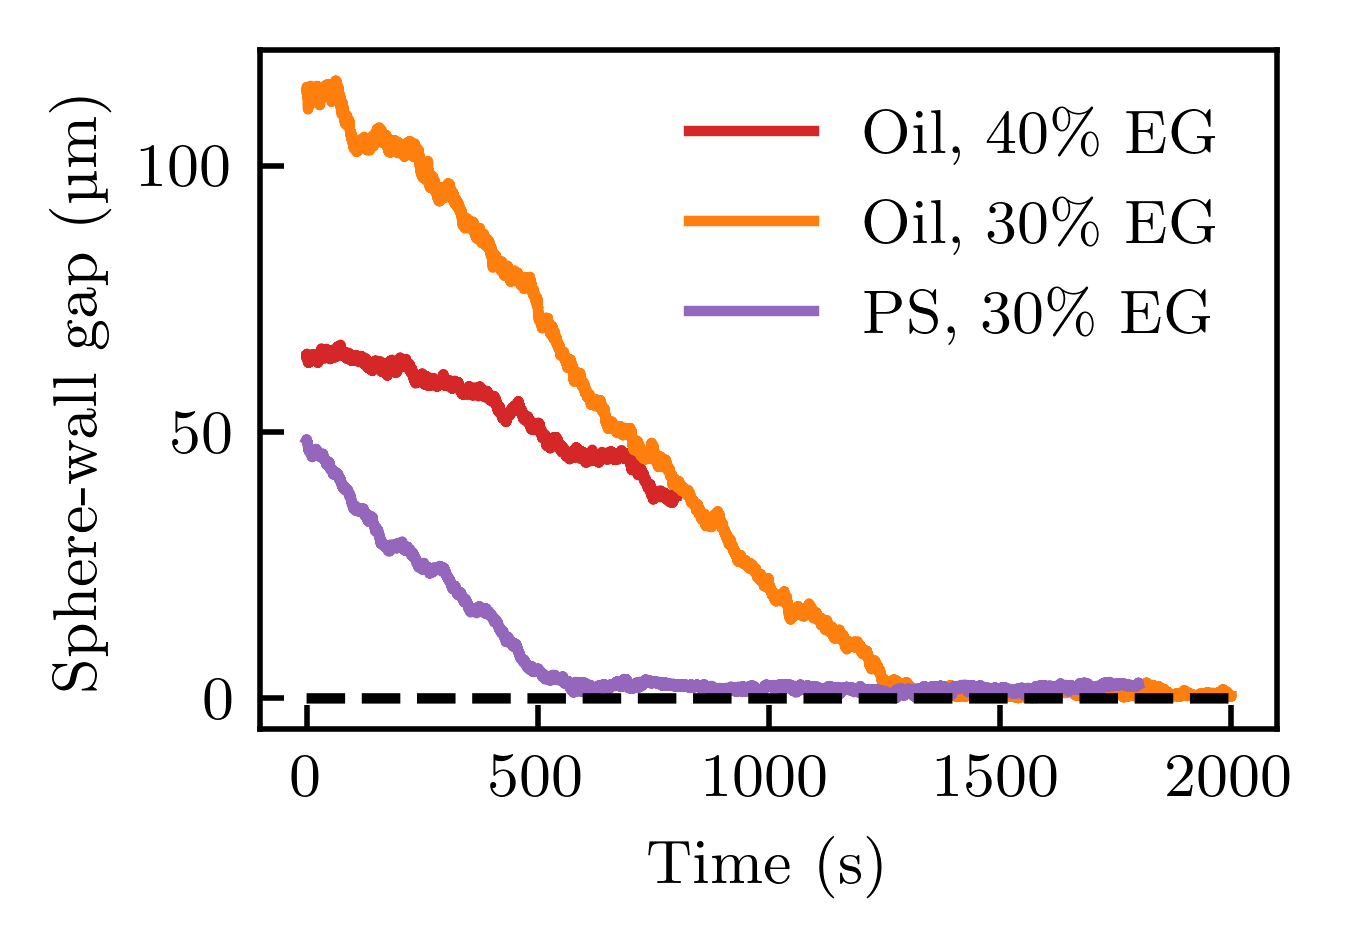

In [177]:
fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

def plot_z(z, fps, wall_position, color='', label='', ax=ax):
    ttt = np.arange(len(z))/fps
    ax.plot(ttt, (z - wall_position) * 1e6, ls='-', c=color, label=label)

plot_z(z1, fps1, wall_1, color='tab:red', label=r'Oil, 40$\%$ EG')
plot_z(z3, fps3, wall_3, color='tab:orange', label=r'Oil, 30$\%$ EG')
plot_z(z4, fps4, wall_4, color='tab:purple', label=r'PS,  30$\%$ EG')

ttt = np.arange(len(z3)) / fps3
ax.plot(ttt, np.zeros(len(z3)), ls='--', c='k')

ax.legend(frameon=False)
ax.set(
    xlabel="Time (s)",
    ylabel=r"Sphere-wall gap (µm)",
    xscale='linear', 
    yscale='linear', 
)

# annotation.slope_marker((600, 50), (-1, 1), invert=False, ax=ax)

plt.tight_layout()
plt.show()

# fig.savefig('fig_pres_sedimentations_z.pdf')

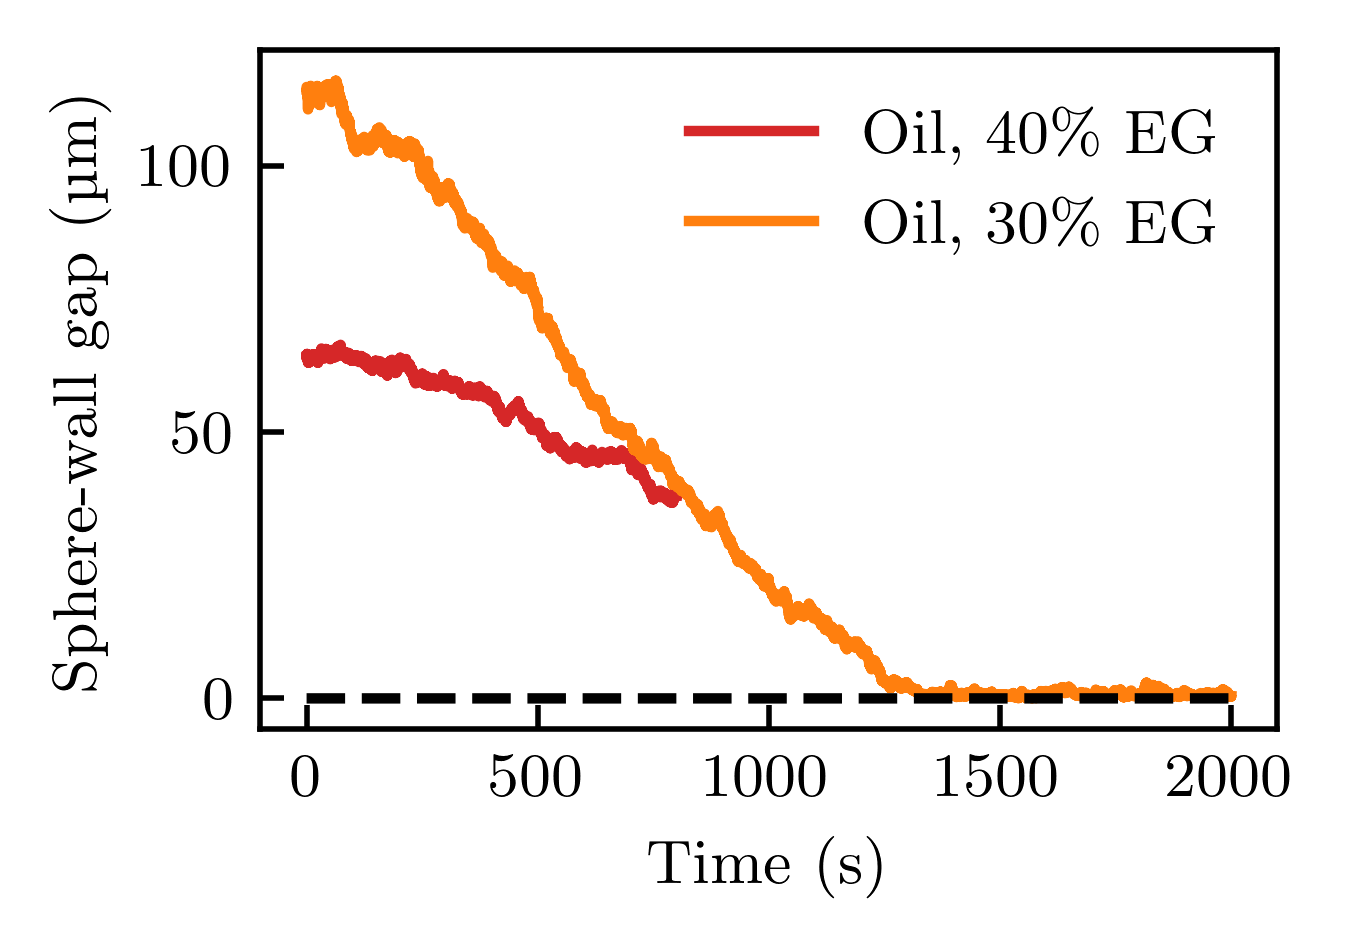

In [180]:
fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

def plot_z(z, fps, wall_position, color='', label='', ax=ax):
    ttt = np.arange(len(z))/fps
    ax.plot(ttt, (z - wall_position) * 1e6, ls='-', c=color, label=label)

plot_z(z1, fps1, wall_1, color='tab:red', label=r'Oil, 40$\%$ EG')
plot_z(z3, fps3, wall_3, color='tab:orange', label=r'Oil, 30$\%$ EG')

ttt = np.arange(len(z3)) / fps3
ax.plot(ttt, np.zeros(len(z3)), ls='--', c='k')

ax.legend(frameon=False)
ax.set(
    xlabel="Time (s)",
    ylabel=r"Sphere-wall gap (µm)",
    xscale='linear', 
    yscale='linear', 
)

# annotation.slope_marker((600, 50), (-1, 1), invert=False, ax=ax)

plt.tight_layout()
plt.show()

# fig.savefig('fig_pres_sedimentations_z_AR1000_radius_1p6um.pdf')

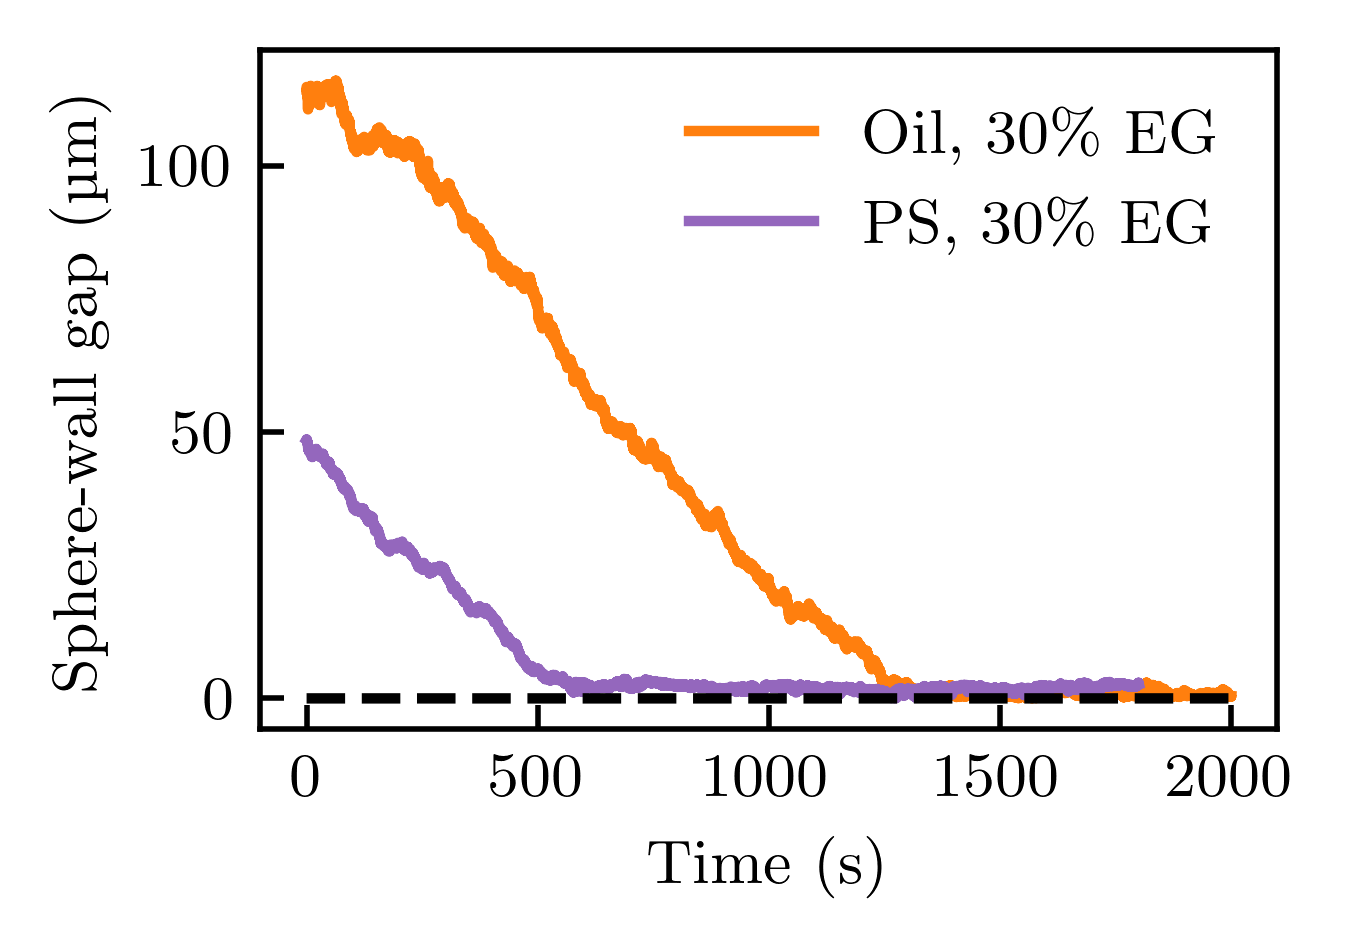

In [182]:
fig, ax = plt.subplots(1, 1, figsize = (7 / 2.54, 5 / 2.54), dpi=500)

def plot_z(z, fps, wall_position, color='', label='', ax=ax):
    ttt = np.arange(len(z))/fps
    ax.plot(ttt, (z - wall_position) * 1e6, ls='-', c=color, label=label)

plot_z(z3, fps3, wall_3, color='tab:orange', label=r'Oil, 30$\%$ EG')
plot_z(z4, fps4, wall_4, color='tab:purple', label=r'PS,  30$\%$ EG')

ttt = np.arange(len(z3)) / fps3
ax.plot(ttt, np.zeros(len(z3)), ls='--', c='k')

ax.legend(frameon=False)
ax.set(
    xlabel="Time (s)",
    ylabel=r"Sphere-wall gap (µm)",
    xscale='linear', 
    yscale='linear', 
)

# annotation.slope_marker((600, 50), (-1, 1), invert=False, ax=ax)

plt.tight_layout()
plt.show()

# fig.savefig('fig_pres_sedimentations_z_AR1000_radius_1p6um_PS_radius_3um.pdf')